# Reproducible Visualization of Model Evaluation and Interpretability Analyses

This tutorial provides a **fully reproducible, modular visualization pipeline** for evaluating model performance, robustness, and interpretability in RNA–protein interaction studies. 

## Contents Overview

### 6. Landscape of motif contributions
- Visualization:
  - Row-scaled attention heatmaps.
  - Mean contribution curves aligned to motif center (−50 to +50 bp).
- Combined into a single aligned figure per condition (positive / negative).

```{note}
Please download the pre-computed results from `Figshare` first, and place them in the expected directory.
```

In [1]:
library(ggExtra)   # ggMarginal for densigram
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


For each dataset (pos / neg), draw:

- Attention heatmap (row-scaled)

- Mean contribution curve across columns (distance -50..50)

Inputs

- pos: attention_weights_pos.tsv

- neg: attention_weights_neg.tsv


In [2]:
library(pheatmap)
library(ggplot2)
library(gridExtra)
library(readr)



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [3]:
load_attention_matrix <- function(path) {
  #' Load attention weights as a numeric matrix.
  #'
  #' Supports:
  #' - .tsv (no header)
  
  # TSV fallback
  mat <- as.matrix(readr::read_tsv(path, col_names = FALSE, show_col_types = FALSE))
  mat
}


In [4]:
make_heatmap_and_curve <- function(mat,
                                   palette = c("#ffffff", "#F3F7FB", "#22466e")) {
  #' Create pheatmap object + curve ggplot from an attention matrix.
  #'
  #' Requirements:
  #' - mat has 101 columns corresponding to distance -50..50
  
  avg_contrib <- colMeans(mat, na.rm = TRUE)
  dist_to_motif <- seq(-50, 50, by = 1)
  
  if (length(avg_contrib) != length(dist_to_motif)) {
    stop("Column count mismatch: expected 101 columns (-50..50), got ", length(avg_contrib))
  }
  
  heatmap_data <- data.frame(
    Distance_to_motif = dist_to_motif,
    Avg_contrib_score = avg_contrib
  )
  
  p_hm <- pheatmap(
    mat,
    scale = "row",
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    show_rownames = FALSE,
    show_colnames = FALSE,
    color = colorRampPalette(palette)(10),
    border_color = "black",
    legend = FALSE,
    annotation_col = NULL,
    silent = TRUE
  )
  
  p_curve <- ggplot(heatmap_data, aes(x = Distance_to_motif, y = Avg_contrib_score)) +
    geom_line(color = "#2e5e94") +
    theme_minimal() +
    labs(x = "Distance to motif center (bp)") +
    theme(
      axis.title.y = element_blank(),
      axis.text.y  = element_blank(),
      axis.ticks.y = element_blank(),
      axis.ticks.x = element_blank(),
      axis.text.x  = element_text(angle = 0, hjust = 1),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_rect(color = "gray", fill = NA, linewidth = 1),
      axis.ticks = element_line(color = "black")
    )
  
  list(heatmap = p_hm, curve = p_curve)
}


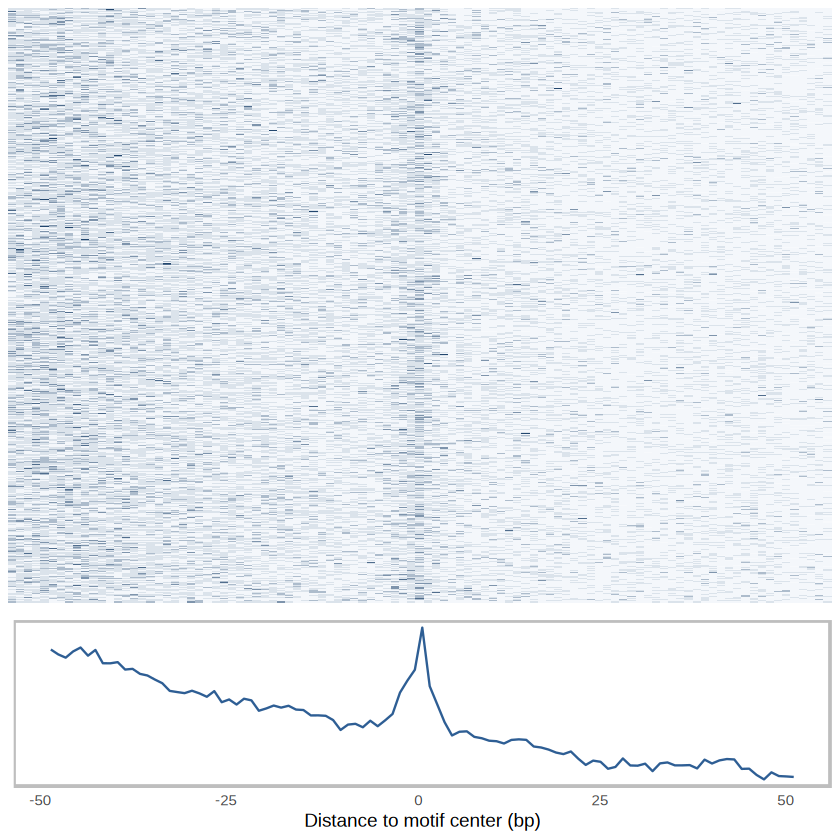

In [5]:
pos_tsv <- paste0("attention_weights_pos.tsv")

pos_path <- pos_tsv

mat_pos <- load_attention_matrix(pos_path)

pos_plots <- make_heatmap_and_curve(mat_pos)

combined_pos <- grid.arrange(
  pos_plots$heatmap$gtable, pos_plots$curve,
  ncol = 1, heights = c(4, 1.5)
)


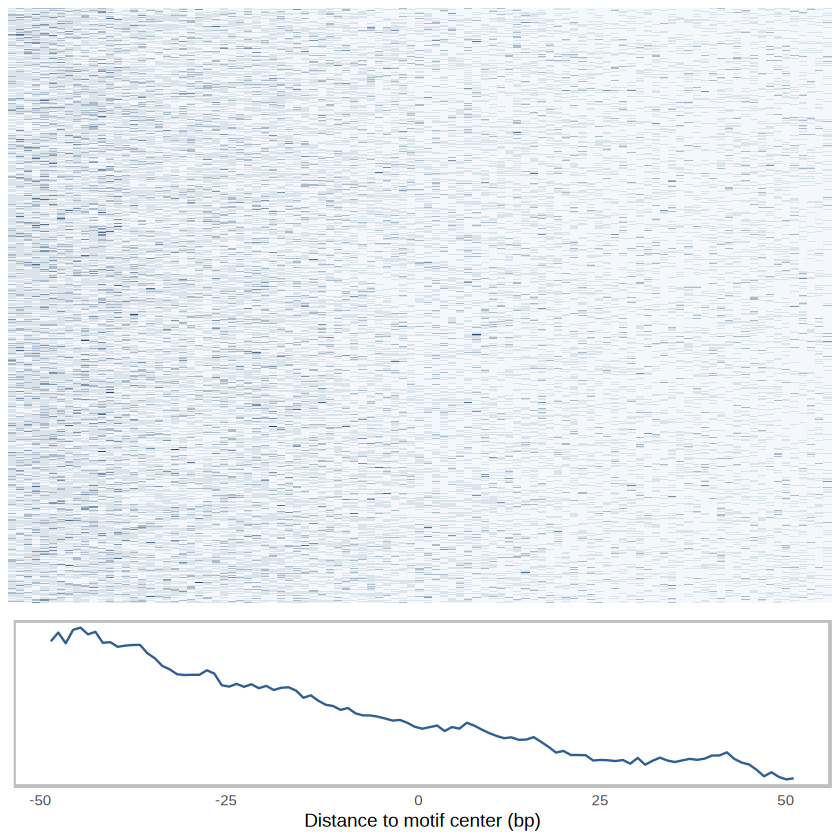

In [6]:
neg_path <- paste0("attention_weights_neg.tsv")

mat_neg <- load_attention_matrix(neg_path)

neg_plots <- make_heatmap_and_curve(mat_neg)

combined_neg <- grid.arrange(
  neg_plots$heatmap$gtable, neg_plots$curve,
  ncol = 1, heights = c(4, 1.5)
)
